# Observe the data and look at class imbalance

In [1]:
# imports
import os
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm import tqdm
import numpy as np

from sklearn.metrics import confusion_matrix



# device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [2]:
# reference training images folder:
train_images_folder = "Data/Training/Training_Images"

# reference csv:
train_csv = "Data/Training/Training_LabelsDemographic.csv"
# load in csv:
train_df = pd.read_csv(train_csv)

# csv columns: 'image', 'myopic_maculopathy_grade', 'age', 'sex', 'height', 'weight', 'data_center'
print("train_csv columns: ", train_df.columns)

# head
print("train_df head: ")
print(train_df.head())

train_csv columns:  Index(['image', 'myopic_maculopathy_grade', 'age', 'sex', 'height', 'weight',
       'data_center'],
      dtype='str')
train_df head: 
                        image  myopic_maculopathy_grade  age   sex  height  \
0  mmac_task_1_train_0001.png                         0   51  male   183.5   
1  mmac_task_1_train_0002.png                         0   51  male   183.5   
2  mmac_task_1_train_0003.png                         0   50  male   184.5   
3  mmac_task_1_train_0004.png                         0   50  male   184.5   
4  mmac_task_1_train_0005.png                         0   49  male   184.5   

   weight  data_center  
0    78.9            1  
1    78.9            1  
2    81.7            1  
3    81.7            1  
4    82.2            1  


In [3]:
# show values in myopic_maculopathy_grade
print("myopic_maculopathy_grade values: ", train_df["myopic_maculopathy_grade"].unique())
# grade 0 to 4

myopic_maculopathy_grade values:  [0 1 2 3 4]


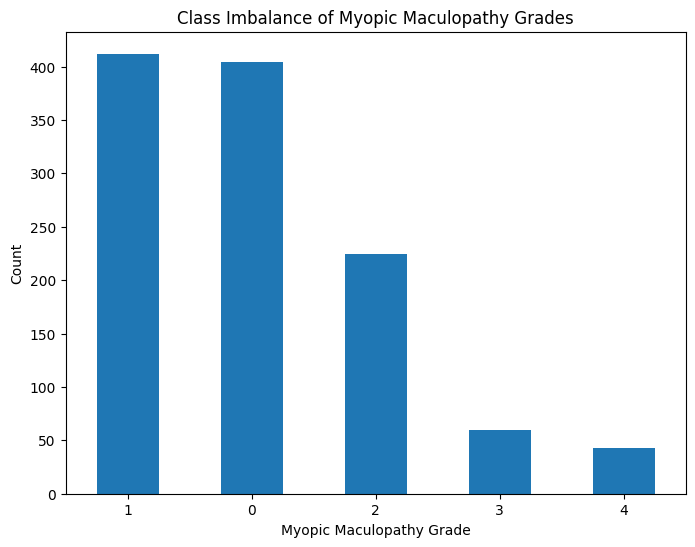

Grade 0: 404 images
Grade 1: 412 images
Grade 2: 224 images
Grade 3: 60 images
Grade 4: 43 images


In [4]:
# bar chart of class imbalance
plt.figure(figsize=(8, 6))
train_df["myopic_maculopathy_grade"].value_counts().plot(kind="bar")
plt.title("Class Imbalance of Myopic Maculopathy Grades")
plt.xlabel("Myopic Maculopathy Grade")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# print number of images in each grade:
for grade in range(5):
    grade_count = train_df[train_df["myopic_maculopathy_grade"] == grade].shape[0]
    print(f"Grade {grade}: {grade_count} images")

Class 0 and 1 are fairly well balance - there are far less images with grade 2, 3 and 4.

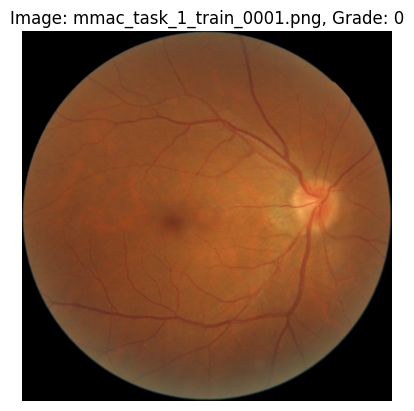

Image shape:  (800, 800)
Min pixel value:  (0, 0, 0)
Max pixel value:  (251, 163, 92)


/var/folders/q3/f8bspqwx7l54y8mwlwq7gq240000gn/T/ipykernel_26888/4050253628.py:12: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  print("Min pixel value: ", min(image.getdata()))
/var/folders/q3/f8bspqwx7l54y8mwlwq7gq240000gn/T/ipykernel_26888/4050253628.py:13: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  print("Max pixel value: ", max(image.getdata()))


In [5]:
# load an image and show it
image_path = os.path.join(train_images_folder, train_df["image"][0])

image = Image.open(image_path).convert("RGB") # matplotlib expects RGB, PIL loads RGBA, so we need to convert it first
plt.imshow(image)
plt.title(f"Image: {train_df['image'][0]}, Grade: {train_df['myopic_maculopathy_grade'][0]}")
plt.axis("off")
plt.show()

# print image shape and values:
print("Image shape: ", image.size)
print("Min pixel value: ", min(image.getdata()))
print("Max pixel value: ", max(image.getdata()))

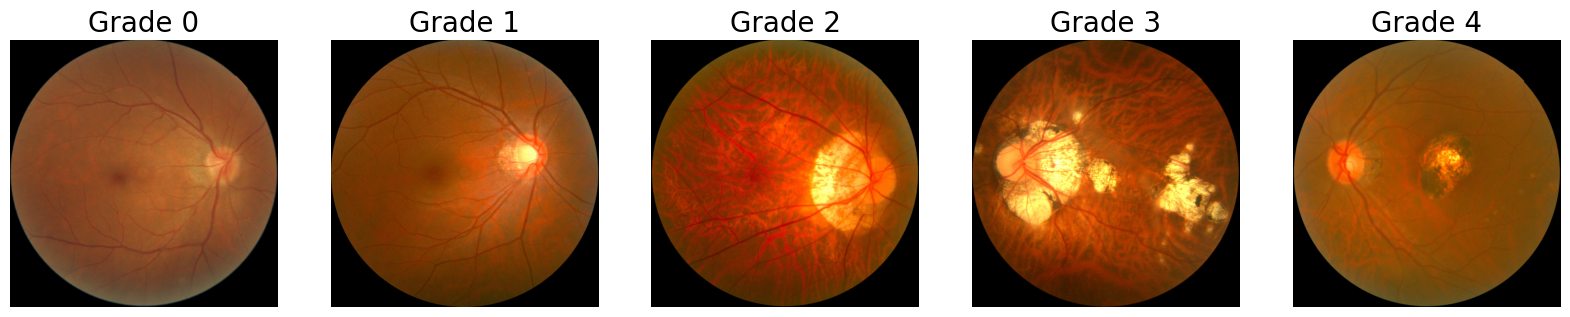

In [6]:
# view an example image from each class:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for grade in range(5):
    grade_image_path = os.path.join(train_images_folder, train_df[train_df["myopic_maculopathy_grade"] == grade]["image"].iloc[0]) # get first image path for this grade
    grade_image = Image.open(grade_image_path).convert("RGB") # to rgb
    
    axes[grade].imshow(grade_image)
    axes[grade].set_title(f"Grade {grade}", fontsize=20)
    axes[grade].axis("off")
plt.show()

We can see that the optic nerve can be on either side of the image, so it is worth addressing this in data augmentation - i.e. we definitely need horizontal flip at minimum.

test set class imbalance: 
myopic_maculopathy_grade
0    80
1    78
2    65
4    13
3    12
Name: count, dtype: int64


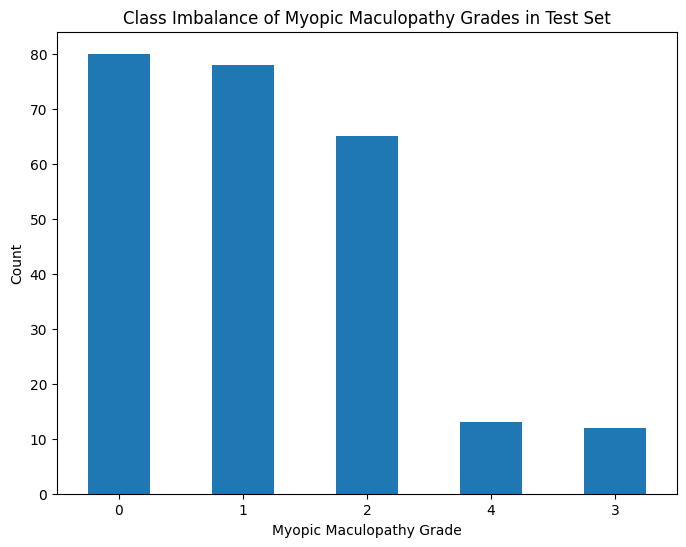

In [7]:
# we can also look at the class imbalance in the test set:
test_csv = "Data/Testing/Testing_LabelDemographic.csv"
test_df = pd.read_csv(test_csv)
print("test set class imbalance: ")
print(test_df["myopic_maculopathy_grade"].value_counts())
plt.figure(figsize=(8, 6))
test_df["myopic_maculopathy_grade"].value_counts().plot(kind="bar")
plt.title("Class Imbalance of Myopic Maculopathy Grades in Test Set")
plt.xlabel("Myopic Maculopathy Grade")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

The training and testing set have similar distributions - this is useful

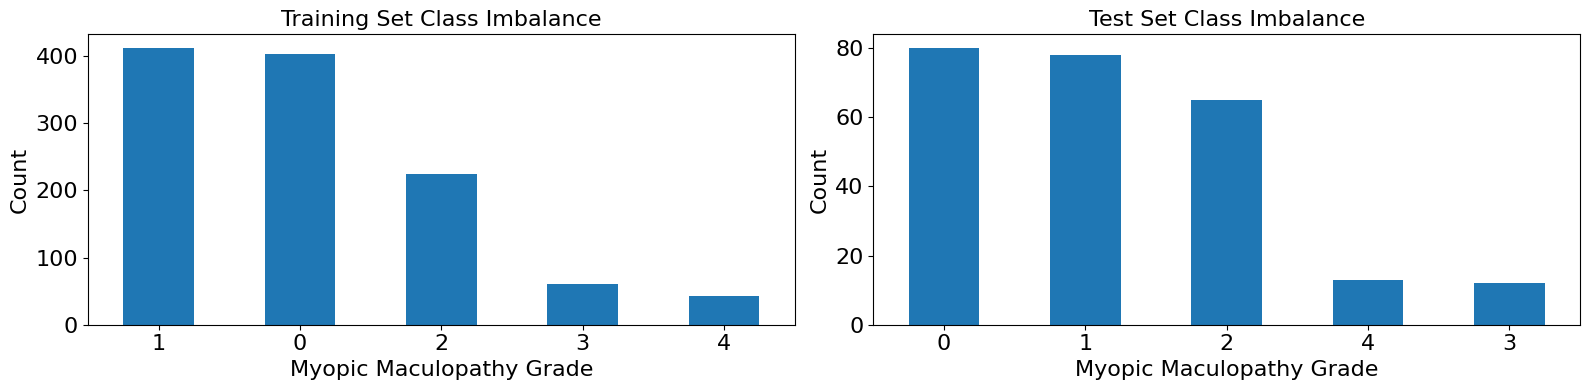

In [8]:
# show the training and test class imbalance plots side by side:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

train_df["myopic_maculopathy_grade"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Training Set Class Imbalance", fontsize=16)
axes[0].set_xlabel("Myopic Maculopathy Grade", fontsize=16)
axes[0].set_ylabel("Count", fontsize=16)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
# bigger ticks:
axes[0].tick_params(axis="both", which="major", labelsize=16)

test_df["myopic_maculopathy_grade"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Test Set Class Imbalance", fontsize=16)
axes[1].set_xlabel("Myopic Maculopathy Grade", fontsize=16)
axes[1].set_ylabel("Count", fontsize=16)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
# bigger ticks:
axes[1].tick_params(axis="both", which="major", labelsize=16)
plt.tight_layout()
plt.show()

# Basic CNN classifier for myopic maculopathy:

#### Imports:

#### Set up a custom dataset class and transformations for ease of use:

In [9]:
# define a custom dataset class for loading the images and labels
class MyopicMaculopathyDataset(Dataset):
    def __init__(self, csv_file, images_folder, transform=None):
        self.data = pd.read_csv(csv_file)
        self.images_folder = images_folder
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = os.path.join(self.images_folder, self.data.iloc[idx]["image"])
        image = Image.open(img_name).convert("RGB") # RGBA to RGB
        label = self.data.iloc[idx]["myopic_maculopathy_grade"] # corresponding 0-4 label
        if self.transform:
            image = self.transform(image) # apply transform
        return image, label



In [10]:
# define transformations for the images

# compute training-set RGB mean/std (after resizing) for normalisation
stats_resize = (224, 224)
channel_sum = np.zeros(3, dtype=np.float64)
channel_sq_sum = np.zeros(3, dtype=np.float64)
num_pixels = 0

for filename in train_df["image"]:
    img_path = os.path.join(train_images_folder, filename)
    img = Image.open(img_path).convert("RGB").resize(stats_resize)
    arr = np.asarray(img, dtype=np.float32) / 255.0  # [H, W, C] in [0, 1]
    flat = arr.reshape(-1, 3)
    channel_sum += flat.sum(axis=0)
    channel_sq_sum += (flat ** 2).sum(axis=0)
    num_pixels += flat.shape[0]

train_mean = (channel_sum / num_pixels).tolist()
train_std = np.sqrt(channel_sq_sum / num_pixels - np.array(train_mean) ** 2).tolist()
print("train_mean:", train_mean)
print("train_std:", train_std)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # keep full RGB channels
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
    # this applies (x - mean)/(std per channel)
 ])

train_mean: [0.43155672973894904, 0.21262072526255182, 0.05879379318795628]
train_std: [0.2834394277616389, 0.162047321157112, 0.0910429572794565]


We first set image size to 224x224, as this is the size used by ResNet18 for their pre-trained weights. This is large enough for our purposes.

We add random horizontal and vertical flip to simulate left and right eye images, and different camera orientations. Futhermore, we want the model to predict actual maculopathy patterns/shapes, rather than looking in the same place(s) generally for each input image.

#### Dataloader + view some transformed images

In [11]:
# create dataset and dataloader
dataset = MyopicMaculopathyDataset(csv_file=train_csv, images_folder=train_images_folder, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)



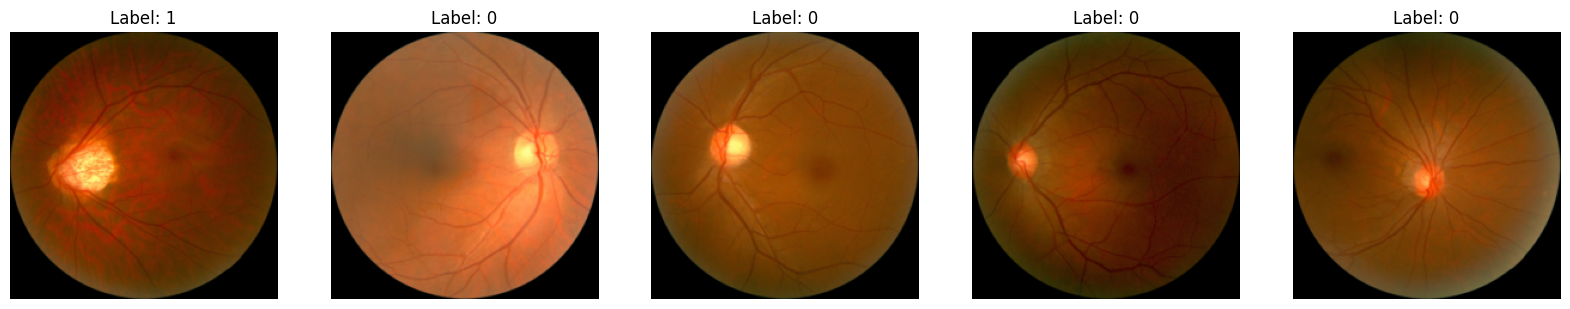

In [12]:
# visualise the transformed images
dataiter = iter(dataloader)
images, labels = next(dataiter)

# show a few transformed images
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    img = images[i].permute(1, 2, 0).numpy()  # [C, H, W] to [H, W, C]
    img = (img * np.array(train_std) + np.array(train_mean)).clip(0, 1)  # unnormalize
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis("off")
plt.show()



#### Set up and train a model:

In [14]:
# now set up and train a ResNet model, keeping in mind that we have RGB images:
model = models.resnet18(pretrained=True) # load pretrained ResNet
# modify the final layer to output 5 classes (grades 0-4)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5)
model = model.to(device) # move model weights to same device as inputs

# define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# training loop
num_epochs = 24
# use tqdm to show progress bar:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

torch.save(model.state_dict(), "myopic_maculopathy_resnet18_normal.pth")

Epoch 1/24: 100%|██████████| 36/36 [00:14<00:00,  2.51it/s]


Epoch 1/24, Loss: 0.9075


Epoch 2/24: 100%|██████████| 36/36 [00:14<00:00,  2.43it/s]


Epoch 2/24, Loss: 0.6258


Epoch 3/24: 100%|██████████| 36/36 [00:14<00:00,  2.44it/s]


...

Epoch 22/24, Loss: 0.1690


Epoch 23/24: 100%|██████████| 36/36 [00:14<00:00,  2.48it/s]


Epoch 23/24, Loss: 0.2093


Epoch 24/24: 100%|██████████| 36/36 [00:14<00:00,  2.53it/s]

Epoch 24/24, Loss: 0.1861


#### Evaluate the model on the training set:

In [13]:
# set up the model
model = models.resnet18(pretrained=True)  # load pretrained ResNet
# modify the final layer to output 5 classes (grades 0-4)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5)
# load the saved weights
state_dict = torch.load("myopic_maculopathy_resnet18_normal.pth", map_location=device)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
# set up a new dataloader for evaluation on training set (no random augmentation, but still tensor + normalization)
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # keep full RGB channels
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
    # this applies (x - mean)/(std per channel)
])

dataset = MyopicMaculopathyDataset(
    csv_file=train_csv,
    images_folder=train_images_folder,
    transform=eval_transform,
 )
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

In [15]:
# function to evaluate model on a given dataloader and return per-class accuracy
# accuracy is the number of correct predictions for each class divided by the total number of samples for that class
def evaluate_model(model, dataloader):
    model.eval()
    correct_per_class = [0] * 5
    total_per_class = [0] * 5
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device, dtype=torch.long)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            for i in range(len(labels)):
                label = labels[i].item()
                total_per_class[label] += 1
                if predicted[i].item() == label:
                    correct_per_class[label] += 1
    accuracy_per_class = [correct / total if total > 0 else 0 for correct, total in zip(correct_per_class, total_per_class)]
    return accuracy_per_class

In [16]:
# function to take accuracy per class and plot it as a bar chart
def plot_accuracy_per_class(accuracy_per_class):
    plt.figure(figsize=(8, 6))
    plt.bar(range(5), accuracy_per_class)
    plt.title("Per-Class Accuracy")
    plt.xlabel("Myopic Maculopathy Grade")
    plt.ylabel("Accuracy")
    plt.xticks(range(5))
    plt.ylim(0, 1)
    plt.show()

In [17]:
# we can also make a function that takes in a model and dataloader, and plots as a bar plot the
# various predictions for each class, to see if the model is only slightly off e.g. by 1 grade
def plot_predictions_per_class(model, dataloader):
    model.eval()
    predictions_per_class = {grade: [] for grade in range(5)}
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device, dtype=torch.long)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            for i in range(len(labels)):
                label = labels[i].item()
                pred = predicted[i].item()
                predictions_per_class[label].append(pred)
    # now plot the distribution of predictions for each true class
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for grade in range(5):
        axes[grade].hist(predictions_per_class[grade], bins=np.arange(-0.5, 5.5, 1), rwidth=0.8)
        axes[grade].set_title(f"True Grade {grade}")
        axes[grade].set_xlabel("Predicted Grade")
        axes[grade].set_ylabel("Count")
        axes[grade].set_xticks(range(5))
    plt.tight_layout()
    plt.show()



# function to show a confusion matrix:
def plot_confusion_matrix(model, dataloader):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device, dtype=torch.long)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds, normalize='true') # normalise to show accuracy per class rather than raw number
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    # show values in each cell:
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", color="white" if cm[i, j] > 0.5 else "black")

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    # colobar with accuracy label: 
    cbar = plt.colorbar()
    cbar.set_label("Accuracy", rotation=270, labelpad=15)

    tick_marks = np.arange(5)
    plt.xticks(tick_marks, tick_marks)
    plt.yticks(tick_marks, tick_marks)
    plt.tight_layout()
    plt.show()

Per-class accuracy:  [0.9975247524752475, 0.6116504854368932, 0.4330357142857143, 0.7833333333333333, 0.9069767441860465]


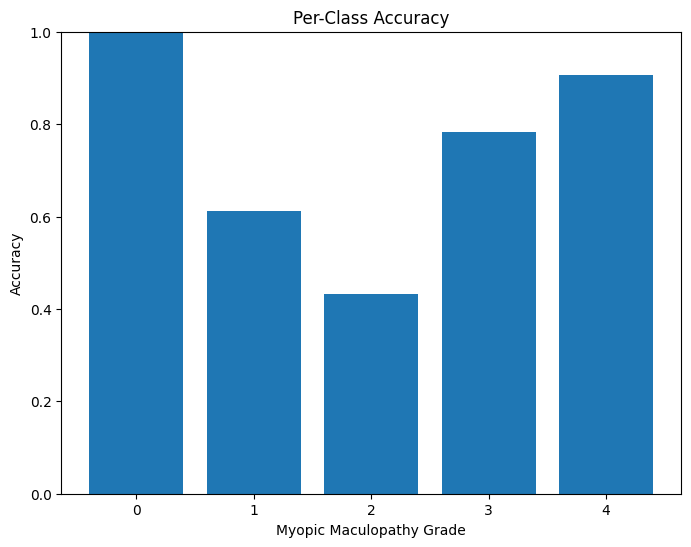

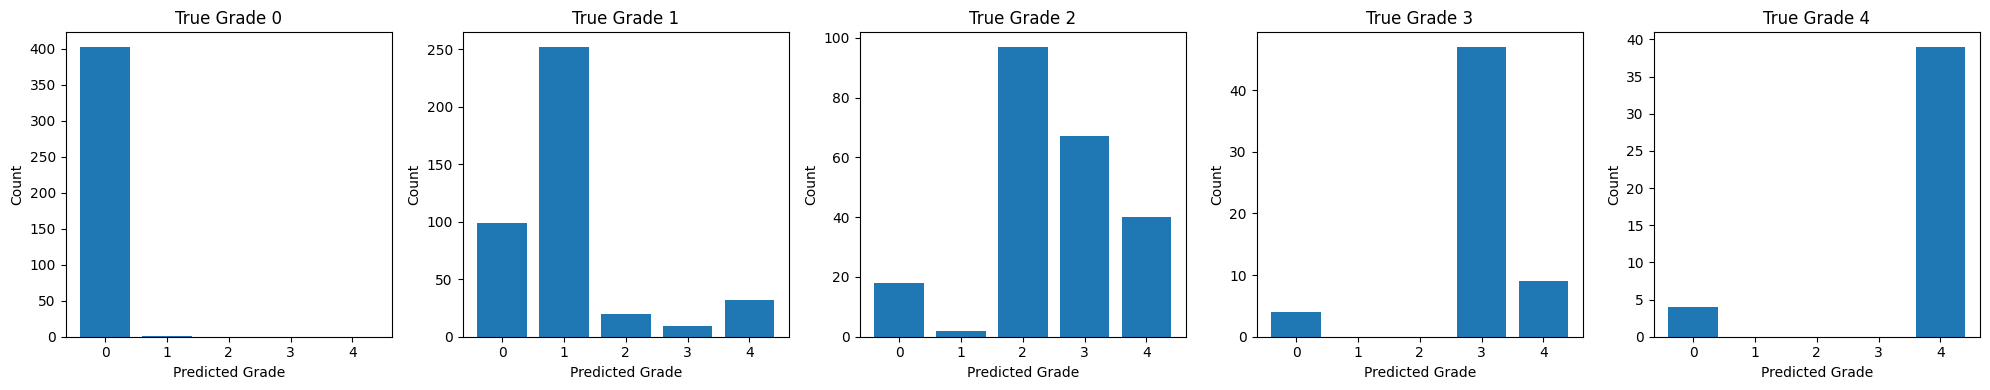

In [18]:
# evaluate model on training set and plot accuracy per class
accuracy_per_class = evaluate_model(model, dataloader)
print("Per-class accuracy: ", accuracy_per_class)
plot_accuracy_per_class(accuracy_per_class)
plot_predictions_per_class(model, dataloader)

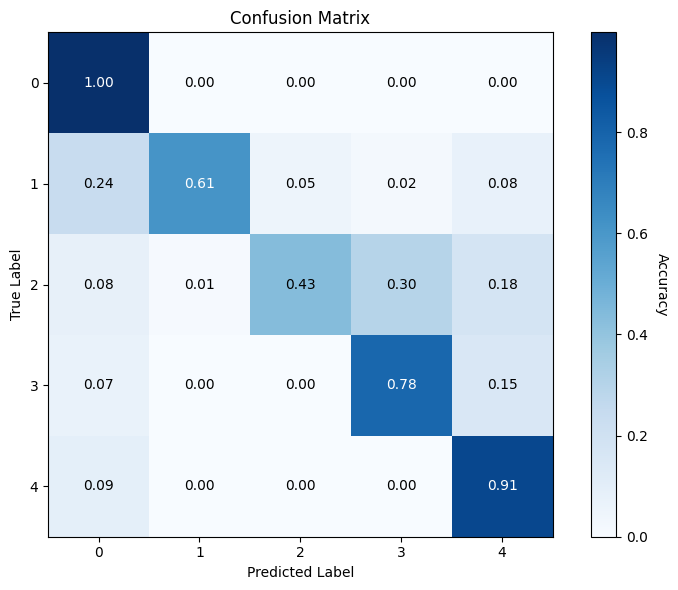

In [19]:
# confusion matrix:
plot_confusion_matrix(model, dataloader)

Useful to remember that the grades are distributed as follows:
- Grade 0: 404 images
- Grade 1: 412 images
- Grade 2: 224 images
- Grade 3: 60 images
- Grade 4: 43 images

#### Evaluate the model on the test set:

Test set per-class accuracy:  [0.9375, 0.5128205128205128, 0.2923076923076923, 0.4166666666666667, 0.6153846153846154]


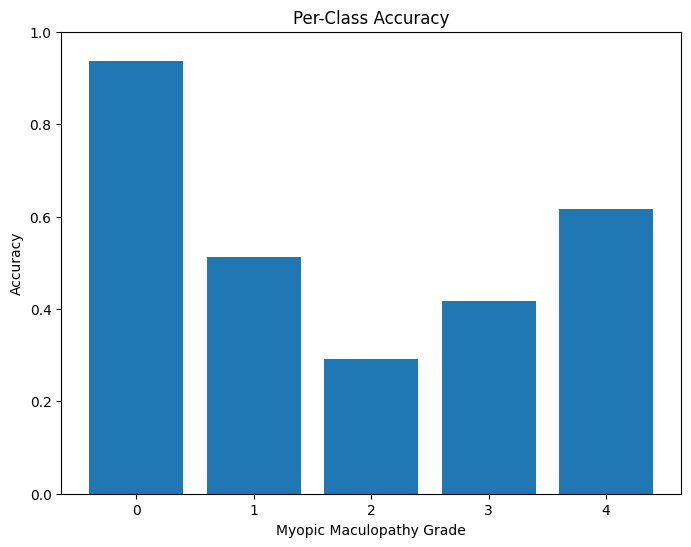

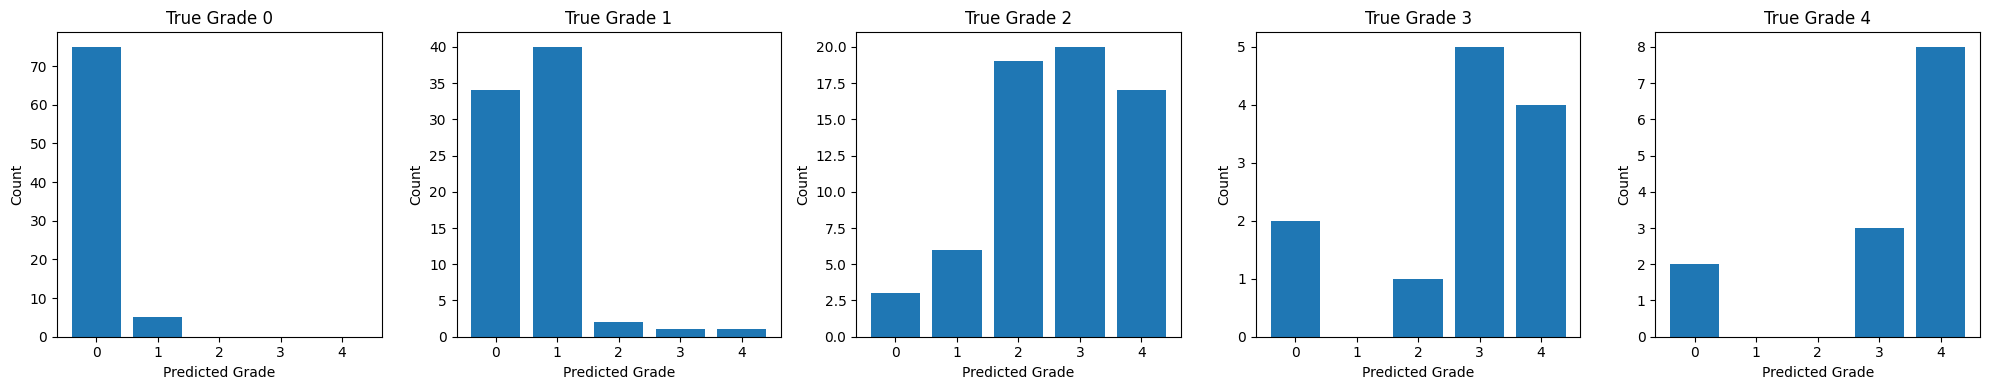

In [20]:
# also evaluate on test set with deterministic preprocessing
test_dataset = MyopicMaculopathyDataset(
    csv_file=test_csv,
    images_folder="Data/Testing/Testing_Images",
    transform=eval_transform,
 )
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)
test_accuracy_per_class = evaluate_model(model, test_dataloader)
print("Test set per-class accuracy: ", test_accuracy_per_class)
plot_accuracy_per_class(test_accuracy_per_class)
plot_predictions_per_class(model, test_dataloader)

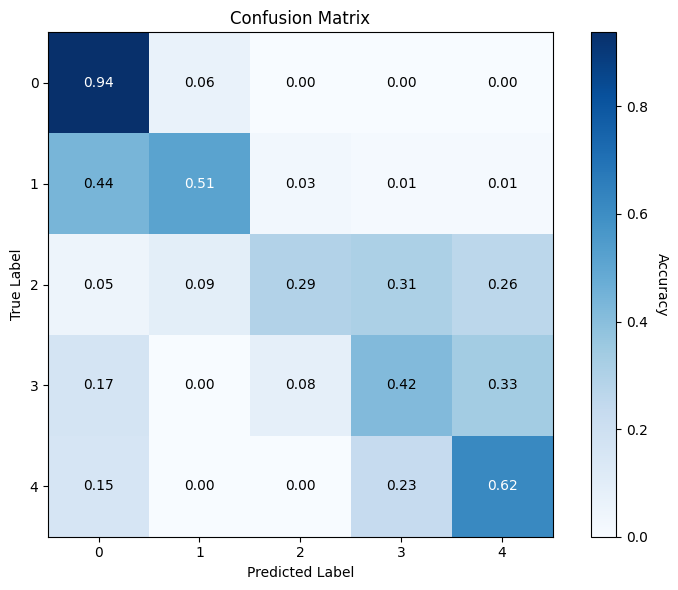

In [21]:
# confusion matrix:
plot_confusion_matrix(model, test_dataloader)

# Class-imbalance resilient CNN for classification

In [ ]:
# now we need to address class imbalance
# we can use class weights in the loss function to give more importance to the minority classes
# this is done by computing the inverse of the class frequencies, and then passing these weights 
# to the CrossEntropyLoss function
class_counts = train_df["myopic_maculopathy_grade"].value_counts().sort_index()
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts) # normalise to number of classes
class_weights = torch.tensor(class_weights.values, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# set up model and optimser as before:
model_class_imbalance = models.resnet18(pretrained=True) # load pretrained ResNet
# modify the final layer to output 5 classes (grades 0-4)
num_ftrs = model_class_imbalance.fc.in_features
model_class_imbalance.fc = nn.Linear(num_ftrs, 5)
model_class_imbalance = model_class_imbalance.to(device)
optimizer = optim.Adam(model_class_imbalance.parameters(), lr=0.001)

# set up dataloader as before:
dataset_class_imbalance = MyopicMaculopathyDataset(csv_file=train_csv, images_folder=train_images_folder, transform=transform)
dataloader = DataLoader(dataset_class_imbalance, batch_size=32, shuffle=True)

# training loop with class weights
num_epochs = 24
# use tqdm to show progress bar:
for epoch in range(num_epochs):
    model_class_imbalance.train()
    running_loss = 0.0
    for images, labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long)
        optimizer.zero_grad()
        outputs = model_class_imbalance(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(dataset_class_imbalance)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

# save the model:
torch.save(model_class_imbalance.state_dict(), "myopic_maculopathy_resnet18_class_weights.pth")

/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/24: 100%|██████████| 36/36 [00:14<00:00,  2.41it/s]


Epoch 1/24, Loss: 1.2466


Epoch 2/24: 100%|██████████| 36/36 [00:14<00:00,  2.55it/s]


Epoch 2/24, Loss: 0.8539


Epoch 3/24: 100%|██████████| 36/36 [00:14<00:00,  2.54it/s]


...

Epoch 22/24, Loss: 0.4658


Epoch 23/24: 100%|██████████| 36/36 [00:14<00:00,  2.49it/s]


Epoch 23/24, Loss: 0.4170


Epoch 24/24: 100%|██████████| 36/36 [00:14<00:00,  2.50it/s]

Epoch 24/24, Loss: 0.3718


In [22]:
# set up the model
model_class_imbalance = models.resnet18(pretrained=True)  # load pretrained ResNet
# modify the final layer to output 5 classes (grades 0-4)
num_ftrs = model_class_imbalance.fc.in_features
model_class_imbalance.fc = nn.Linear(num_ftrs, 5)
# load the saved weights
state_dict = torch.load("myopic_maculopathy_resnet18_class_weights.pth", map_location=device)
model_class_imbalance.load_state_dict(state_dict)
model_class_imbalance = model_class_imbalance.to(device)
model_class_imbalance.eval()

/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [23]:
# set up a new dataloader for evaluation on training set (no random augmentation, but still tensor + normalization)
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # keep full RGB channels
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
    # this applies (x - mean)/(std per channel)
])

dataset = MyopicMaculopathyDataset(
    csv_file=train_csv,
    images_folder=train_images_folder,
    transform=eval_transform,
 )
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

Per-class accuracy with class weights:  [0.900990099009901, 0.9029126213592233, 0.6741071428571429, 0.9833333333333333, 0.7441860465116279]


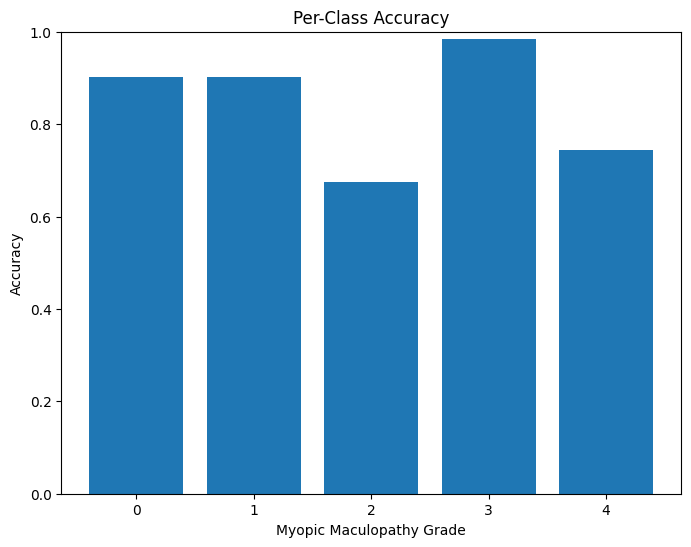

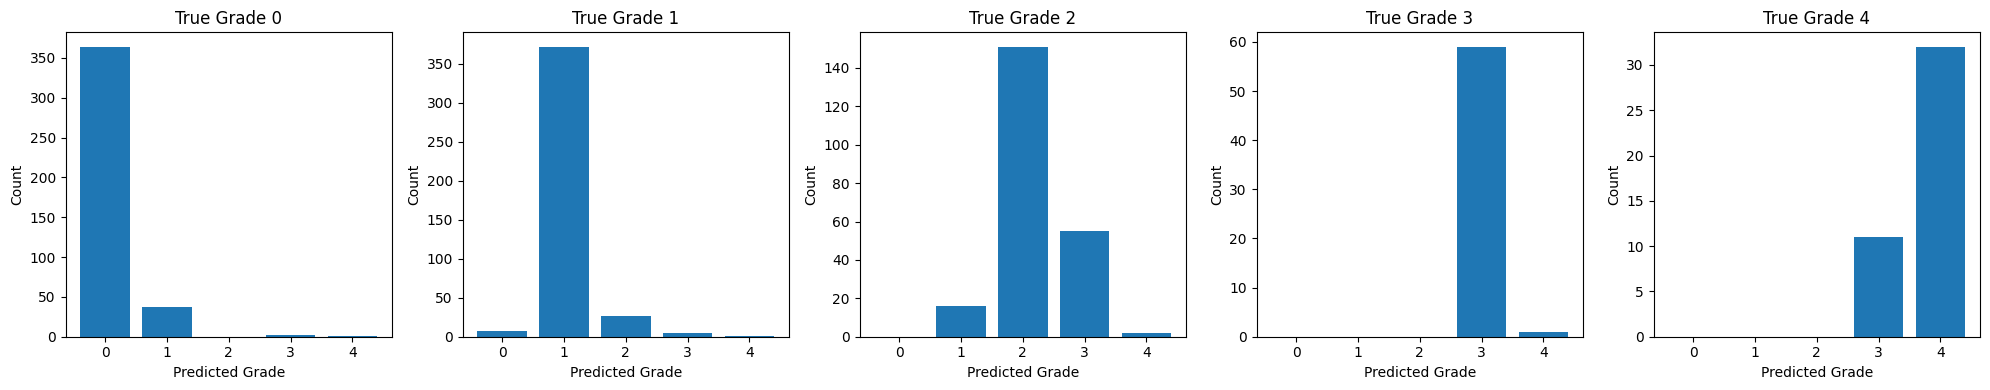

In [24]:
# evaluate on training set
accuracy_per_class_weighted = evaluate_model(model_class_imbalance, dataloader)
print("Per-class accuracy with class weights: ", accuracy_per_class_weighted)
plot_accuracy_per_class(accuracy_per_class_weighted)
plot_predictions_per_class(model_class_imbalance, dataloader)

Test set per-class accuracy with class weights:  [0.7375, 0.7948717948717948, 0.5384615384615384, 0.75, 0.6923076923076923]


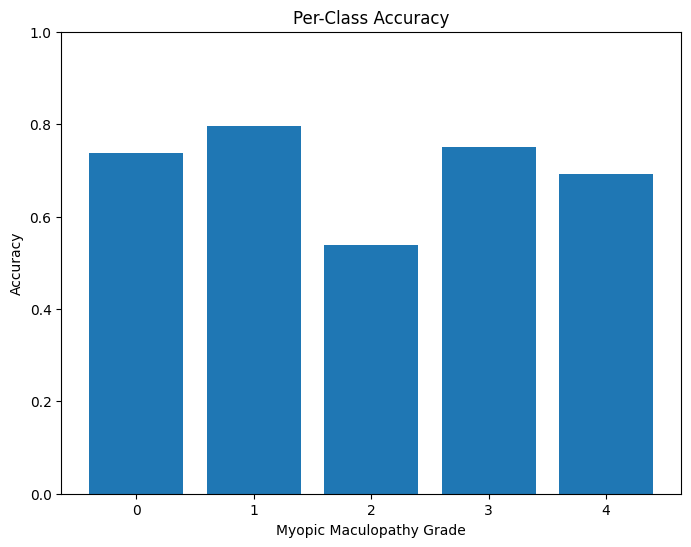

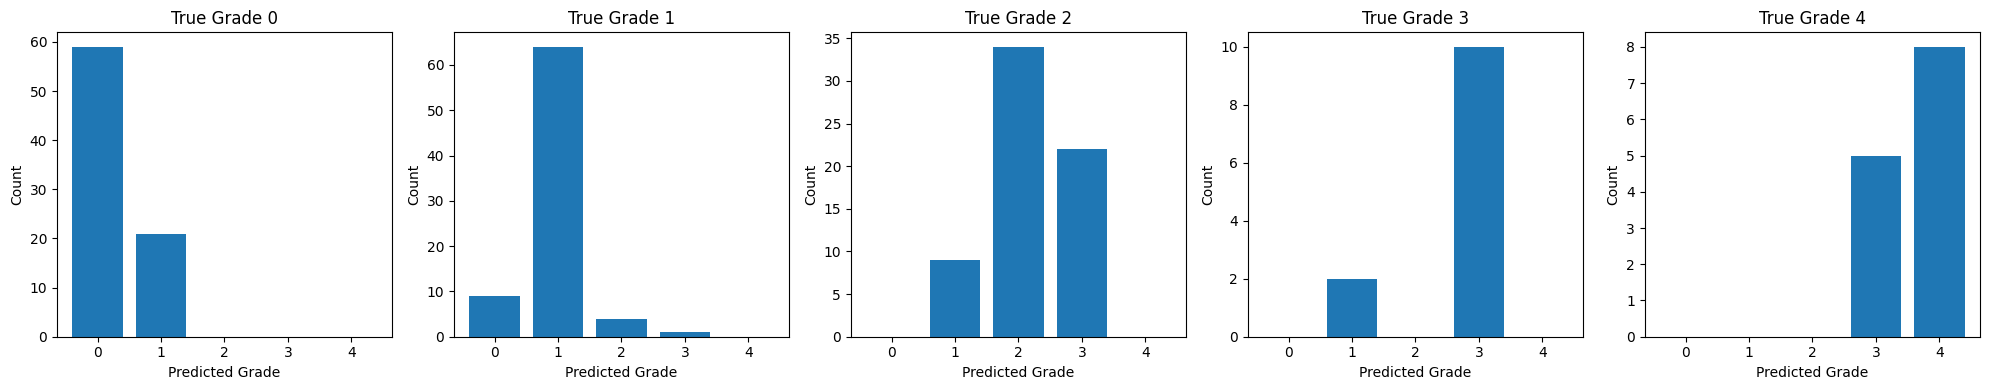

In [25]:
# evaluate on test set:
test_dataset = MyopicMaculopathyDataset(csv_file=test_csv, images_folder="Data/Testing/Testing_Images", transform=transform)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)
test_accuracy_per_class_weighted = evaluate_model(model_class_imbalance, test_dataloader)
print("Test set per-class accuracy with class weights: ", test_accuracy_per_class_weighted)
plot_accuracy_per_class(test_accuracy_per_class_weighted)
plot_predictions_per_class(model_class_imbalance, test_dataloader)

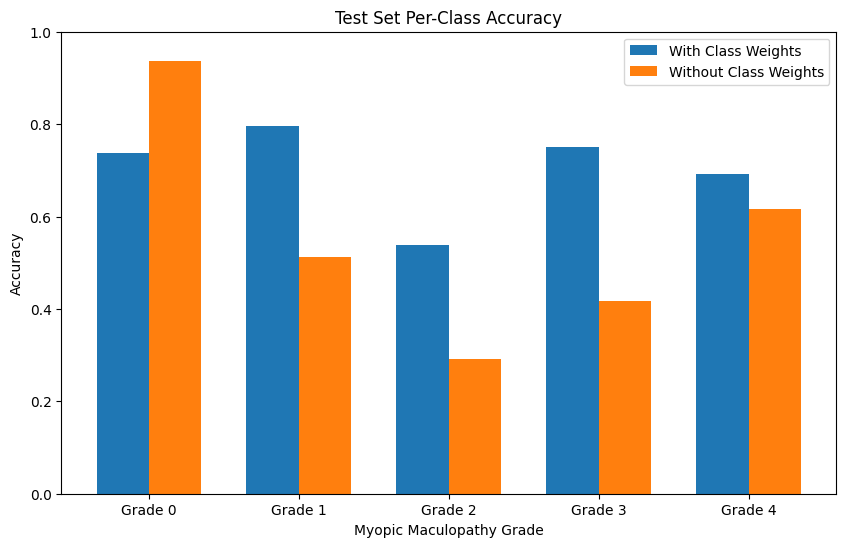

In [26]:
# plot the test accuracy for models with and without class weights on the same plot:
labels = ["Grade 0", "Grade 1", "Grade 2", "Grade 3", "Grade 4"]
x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, test_accuracy_per_class_weighted, width, label="With Class Weights")
plt.bar(x + width/2, test_accuracy_per_class, width, label="Without Class Weights")
plt.title("Test Set Per-Class Accuracy")
plt.xlabel("Myopic Maculopathy Grade")
plt.ylabel("Accuracy")
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.legend()
plt.show()

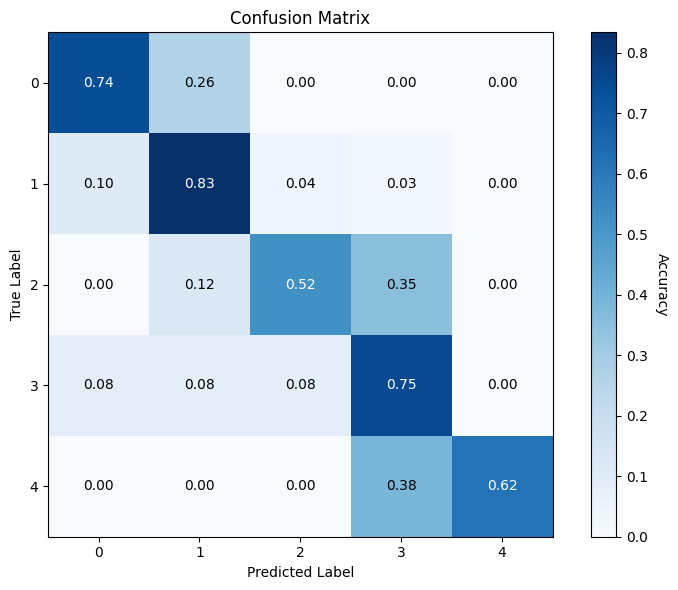

In [27]:
# confusion matrix:
plot_confusion_matrix(model_class_imbalance, test_dataloader)

# Loss function specific class imbalance

In [28]:
# we can also use a specific loss function for imbalanced data, such as focal loss, which gives more weight to hard-to-classify samples.

import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha # tensor of per-class weights or None
        self.gamma = gamma # reduce loss for easier samples
        self.reduction = reduction # how to aggregate loss across the batch

    def forward(self, inputs, targets):
        # per-sample cross-entropy
        ce_loss = F.cross_entropy(inputs, targets, reduction="none")
        pt = torch.exp(-ce_loss) # predicted probability of true class
        focal_loss = (1 - pt) ** self.gamma * ce_loss # focal loss formula

        # apply class weights per sample if provided
        if self.alpha is not None:
            alpha = self.alpha.to(inputs.device) # move alpha to gpu
            focal_loss = alpha[targets] * focal_loss # weight loss by class

        if self.reduction == "mean":
            return focal_loss.mean()
        if self.reduction == "sum":
            return focal_loss.sum()
        return focal_loss
    




# we can use class weights in the loss function to give more importance to the minority classes 
# set class weights for focal loss by computing the inverse of the class frequencies, and then 
# normalising to the number of classes
class_counts = train_df["myopic_maculopathy_grade"].value_counts().sort_index()
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts) # normalise to number of classes
class_weights = torch.tensor(class_weights.values, dtype=torch.float).to(device)
    
# use focal loss in training loop
criterion_focal = FocalLoss(alpha=class_weights, gamma=2.0)


In [29]:

# dataloader
# define transformations for the images
# convert to grayscale, normalise to [0, 1] and resize to 224x224 for ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # keep full RGB channels
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
    # this applies (x - mean)/(std per channel)
 ])

# create dataset and dataloader
dataset = MyopicMaculopathyDataset(csv_file=train_csv, images_folder=train_images_folder, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)


In [33]:
# training loop with focal loss
model_focal_loss = models.resnet18(pretrained=True)  # load pretrained ResNet
num_ftrs = model_focal_loss.fc.in_features
model_focal_loss.fc = nn.Linear(num_ftrs, 5)
model_focal_loss = model_focal_loss.to(device)
optimizer = optim.Adam(model_focal_loss.parameters(), lr=0.001)

num_epochs = 24
for epoch in range(num_epochs):
    model_focal_loss.train()
    running_loss = 0.0
    for images, labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long)
        optimizer.zero_grad()
        outputs = model_focal_loss(images)
        loss = criterion_focal(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(dataloader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

# save the model
torch.save(model_focal_loss.state_dict(), "myopic_maculopathy_resnet18_focal_loss.pth")

/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/24: 100%|██████████| 36/36 [00:14<00:00,  2.47it/s]


Epoch 1/24, Loss: 0.3045


Epoch 2/24: 100%|██████████| 36/36 [00:14<00:00,  2.48it/s]


Epoch 2/24, Loss: 0.1845


Epoch 3/24: 100%|██████████| 36/36 [00:14<00:00,  2.55it/s]


...

Epoch 22/24, Loss: 0.0662


Epoch 23/24: 100%|██████████| 36/36 [00:14<00:00,  2.51it/s]


Epoch 23/24, Loss: 0.0460


Epoch 24/24: 100%|██████████| 36/36 [00:14<00:00,  2.51it/s]

Epoch 24/24, Loss: 0.0482


In [30]:
# load the model for evaluation
model_focal_loss = models.resnet18(pretrained=True)  # load pretrained ResNet
num_ftrs = model_focal_loss.fc.in_features
model_focal_loss.fc = nn.Linear(num_ftrs, 5)
state_dict = torch.load("myopic_maculopathy_resnet18_focal_loss.pth", map_location=device)
model_focal_loss.load_state_dict(state_dict)
model_focal_loss = model_focal_loss.to(device)


/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Per-class accuracy with focal loss:  [0.8316831683168316, 0.8762135922330098, 0.8125, 0.95, 0.9767441860465116]


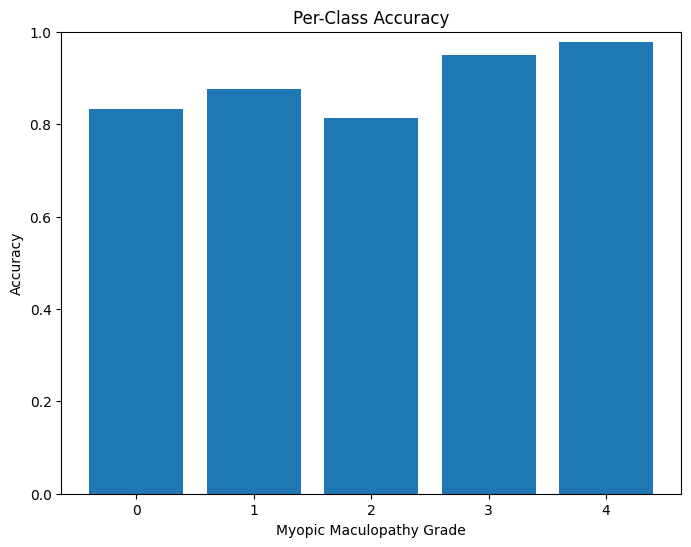

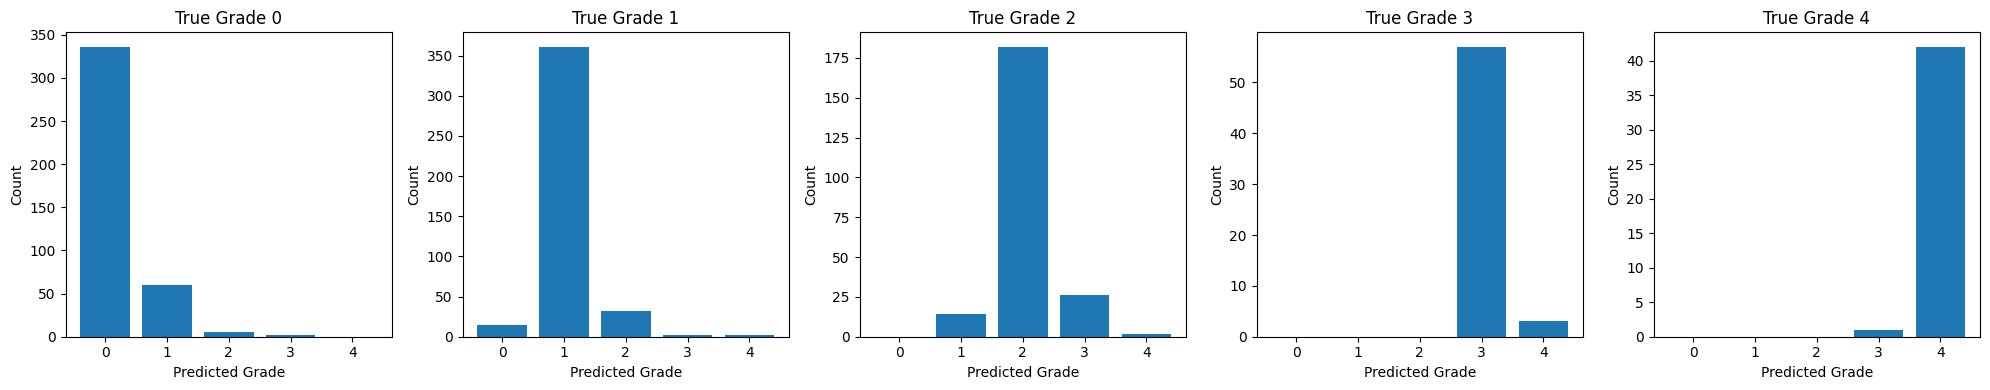

In [31]:

# set up a new dataloader for evaluation on training set (no random augmentation, but still tensor + normalization)
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # keep full RGB channels
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
    # this applies (x - mean)/(std per channel)
])

dataset = MyopicMaculopathyDataset(
    csv_file=train_csv,
    images_folder=train_images_folder,
    transform=eval_transform,
 )
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

# evaluate on training set
accuracy_per_class_focal = evaluate_model(model_focal_loss, dataloader)
print("Per-class accuracy with focal loss: ", accuracy_per_class_focal)
plot_accuracy_per_class(accuracy_per_class_focal)
plot_predictions_per_class(model_focal_loss, dataloader)


Test set per-class accuracy with focal loss:  [0.625, 0.8333333333333334, 0.7076923076923077, 0.8333333333333334, 0.8461538461538461]


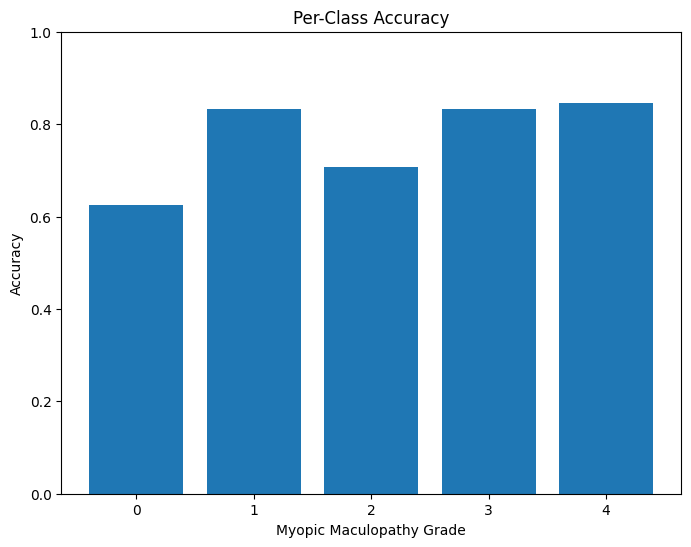

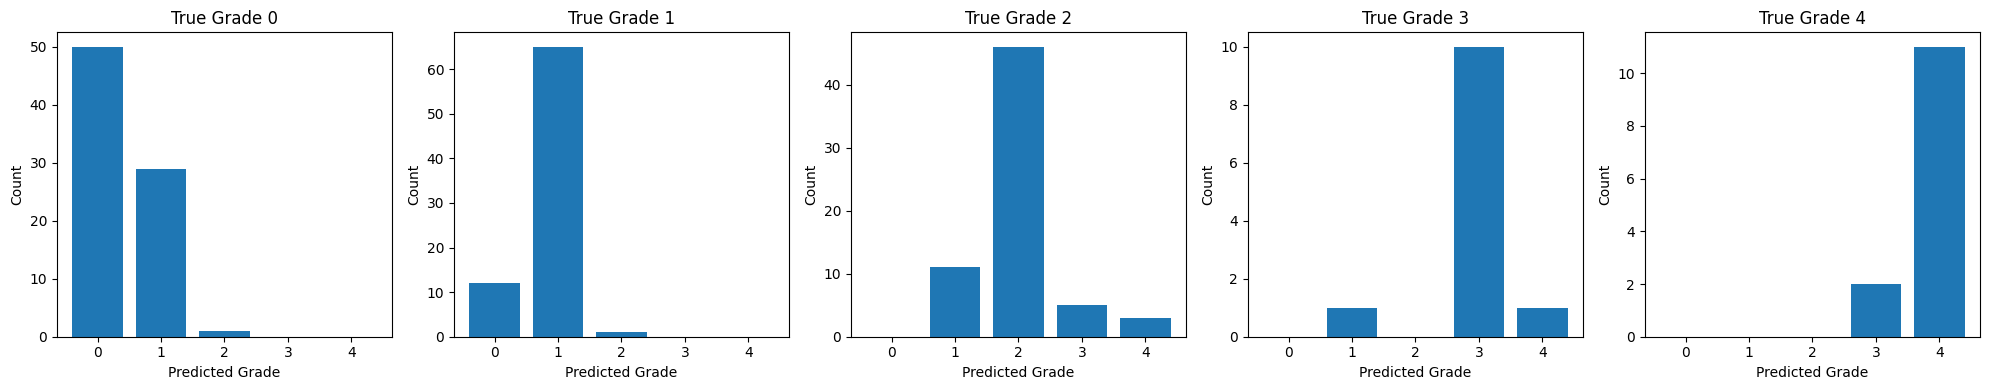

In [32]:
# also evaluate on test set:
test_dataset = MyopicMaculopathyDataset(csv_file=test_csv, images_folder="Data/Testing/Testing_Images", transform=eval_transform)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)
test_accuracy_per_class_focal = evaluate_model(model_focal_loss, test_dataloader)
print("Test set per-class accuracy with focal loss: ", test_accuracy_per_class_focal)
plot_accuracy_per_class(test_accuracy_per_class_focal)
plot_predictions_per_class(model_focal_loss, test_dataloader)

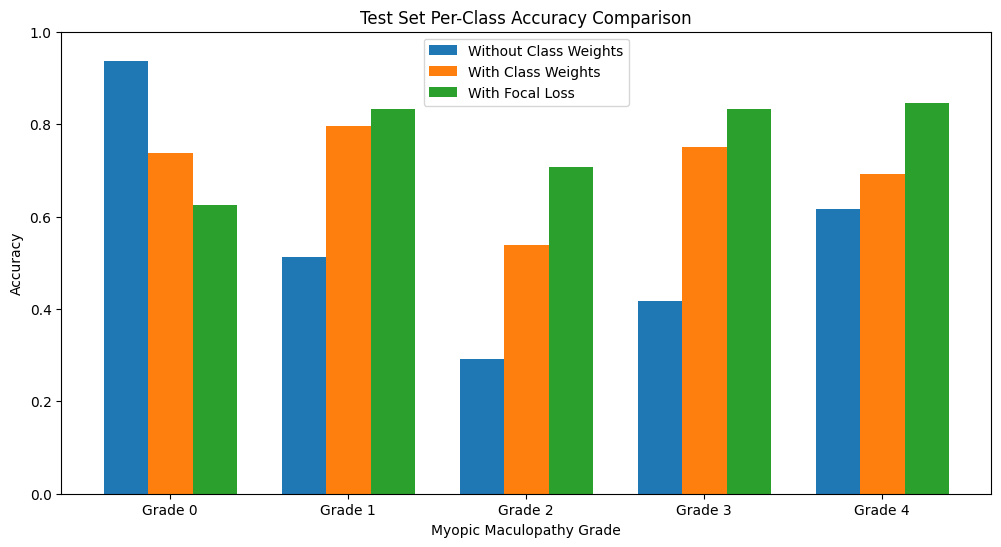

In [33]:
# compare to model without class weights:
labels = ["Grade 0", "Grade 1", "Grade 2", "Grade 3", "Grade 4"]
x = np.arange(len(labels))
width = 0.25
plt.figure(figsize=(12, 6))
plt.bar(x - width, test_accuracy_per_class, width, label="Without Class Weights")
plt.bar(x, test_accuracy_per_class_weighted, width, label="With Class Weights")
plt.bar(x + width, test_accuracy_per_class_focal, width, label="With Focal Loss")
plt.title("Test Set Per-Class Accuracy Comparison")
plt.xlabel("Myopic Maculopathy Grade")
plt.ylabel("Accuracy")
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.legend()
plt.show()  

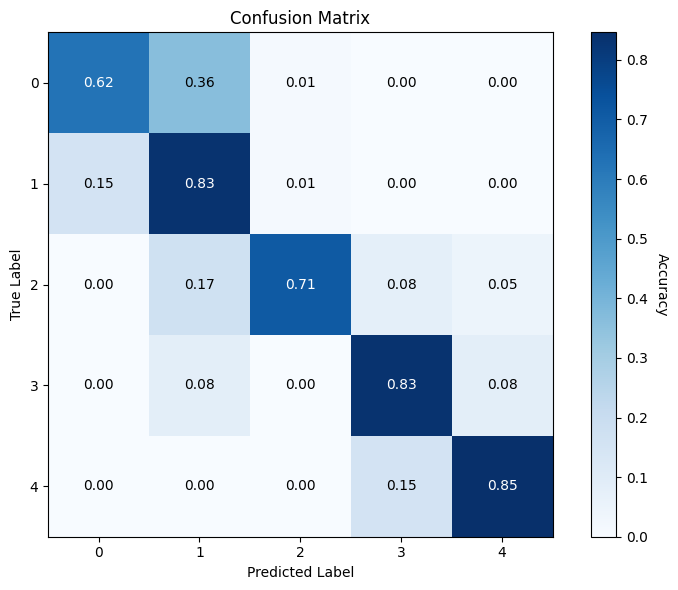

In [34]:
# confusion matrix:
plot_confusion_matrix(model_focal_loss, test_dataloader)

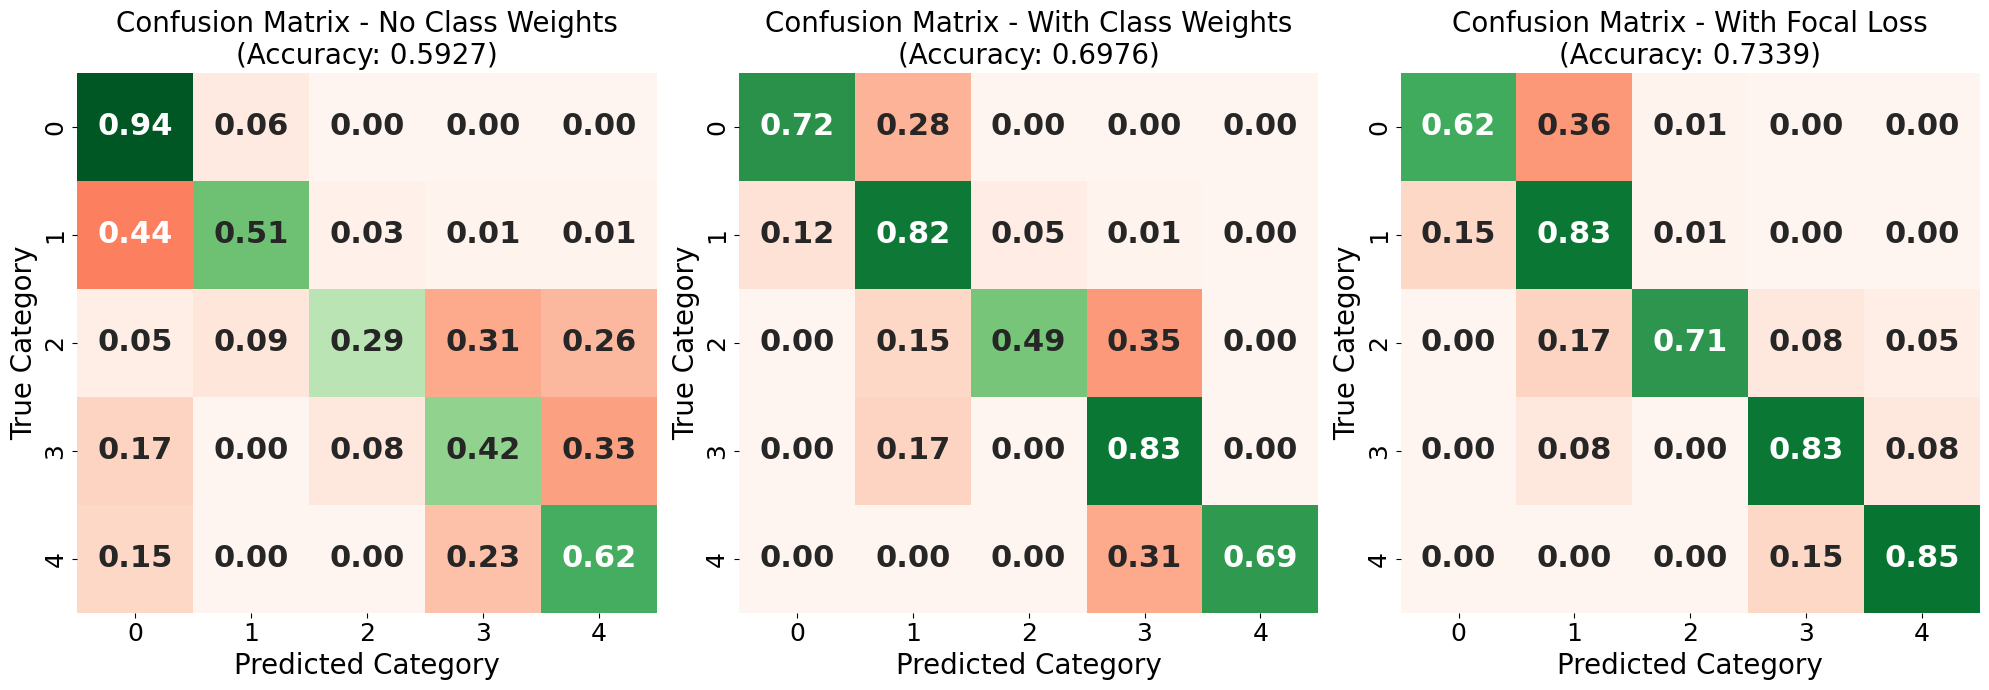

In [71]:
# calculate overall test accuracy for each model:
def compute_overall_accuracy(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device, dtype=torch.long)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return correct / total if total > 0 else 0

def plot_all_confusion_matrices_seaborn(models, dataloader, model_names, figsize=(20, 7)):
    import seaborn as sns
    fig, axes = plt.subplots(1, len(models), figsize=figsize)
    for idx, model in enumerate(models):
        model.eval()
        all_labels = []
        all_preds = []

        with torch.no_grad():
            for images, labels in dataloader:
                images = images.to(device)
                labels = labels.to(device, dtype=torch.long)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(predicted.cpu().numpy())
                
        cm = confusion_matrix(all_labels, all_preds, normalize='true')

        # mask for off diagonals to allow different color schemes for correct/incorrect
        off_diag_mask = np.eye(*cm.shape, dtype=bool)

        sns.heatmap(cm, annot=True, fmt=".2f", cmap="Greens", ax=axes[idx], 
                    mask=~off_diag_mask, cbar=False, vmin=0, vmax=1)
        sns.heatmap(cm, annot=True, fmt=".2f", cmap="Reds", ax=axes[idx], 
                    mask=off_diag_mask, cbar=False, vmin=0, vmax=1)
        
        # calculate overall accuracy for this model and show in title:
        overall_accuracy = compute_overall_accuracy(model, dataloader)

        axes[idx].set_title(f"Confusion Matrix - {model_names[idx]}\n(Accuracy: {overall_accuracy:.4f})", fontsize=20)
        axes[idx].set_xlabel("Predicted Category", fontsize=20)
        axes[idx].set_ylabel("True Category", fontsize=20)

        # bigger annotation size:
        for text in axes[idx].texts:
            text.set_fontsize(22)
            text.set_fontweight("bold")

        # bigger ticks:
        axes[idx].tick_params(axis="both", which="major", labelsize=18)

    plt.tight_layout()
    plt.show()


# plot confusion matrices for all 3 models:
plot_all_confusion_matrices_seaborn(
    models=[model, model_class_imbalance, model_focal_loss],
    dataloader=test_dataloader,
    model_names=["No Class Weights", "With Class Weights", "With Focal Loss"]
)

In [56]:
# train a focal loss model with data augmentation to see if we can further improve performance 
# on the minority classes

# define transformations for the images with more aggressive augmentation
transform_augmented = transforms.Compose([
    transforms.Resize((224, 224)),
    # keep full RGB channels
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.001), # brightness jitter of 0.1% to prevent overfitting to brightness cues
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
    # this applies (x - mean)/(std per channel)
 ])

# create dataset and dataloader with augmented transform
dataset_augmented = MyopicMaculopathyDataset(csv_file=train_csv, images_folder=train_images_folder, transform=transform_augmented)
dataloader_augmented = DataLoader(dataset_augmented, batch_size=32, shuffle=True)

# training loop with focal loss and augmented data
model_focal_augmented = models.resnet18(pretrained=True) # load pretrained ResNet
num_ftrs = model_focal_augmented.fc.in_features
model_focal_augmented.fc = nn.Linear(num_ftrs, 5)
model_focal_augmented = model_focal_augmented.to(device)
optimizer = optim.Adam(model_focal_augmented.parameters(), lr=0.001)

# set up focal loss
class_counts = train_df["myopic_maculopathy_grade"].value_counts().sort_index()
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts) # normalise to number of classes
class_weights = torch.tensor(class_weights.values, dtype=torch.float).to(device)
# use focal loss in training loop
criterion_focal = FocalLoss(alpha=class_weights, gamma=2.0)

# train
num_epochs = 24
for epoch in range(num_epochs):
    model_focal_augmented.train()
    running_loss = 0.0
    for images, labels in tqdm(dataloader_augmented, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long)
        optimizer.zero_grad()
        outputs = model_focal_augmented(images)
        loss = criterion_focal(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(dataloader_augmented.dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

# save the model
torch.save(model_focal_augmented.state_dict(), "myopic_maculopathy_resnet18_focal_augmented.pth")

/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/24: 100%|██████████| 36/36 [00:15<00:00,  2.34it/s]


Epoch 1/24, Loss: 0.3181


Epoch 2/24: 100%|██████████| 36/36 [00:15<00:00,  2.38it/s]


Epoch 2/24, Loss: 0.1670


Epoch 3/24: 100%|██████████| 36/36 [00:15<00:00,  2.39it/s]


...

Epoch 22/24, Loss: 0.0536


Epoch 23/24: 100%|██████████| 36/36 [00:14<00:00,  2.41it/s]


Epoch 23/24, Loss: 0.0523


Epoch 24/24: 100%|██████████| 36/36 [00:14<00:00,  2.40it/s]

Epoch 24/24, Loss: 0.0433


/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


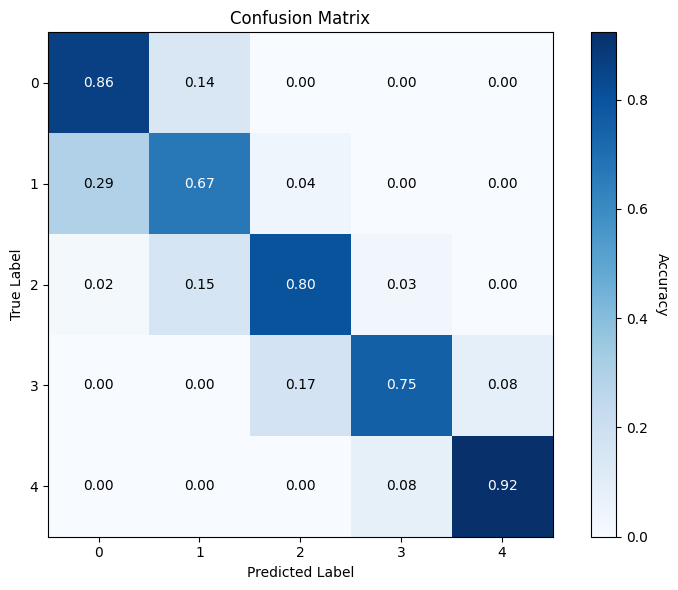

In [57]:
# load the model for evaluation
model_focal_augmented = models.resnet18(pretrained=True)  # load pretrained ResNet
num_ftrs = model_focal_augmented.fc.in_features
model_focal_augmented.fc = nn.Linear(num_ftrs, 5)
state_dict = torch.load("myopic_maculopathy_resnet18_focal_augmented.pth", map_location=device)
model_focal_augmented.load_state_dict(state_dict)
model_focal_augmented = model_focal_augmented.to(device)

# confusion matrix:
plot_confusion_matrix(model_focal_augmented, test_dataloader)

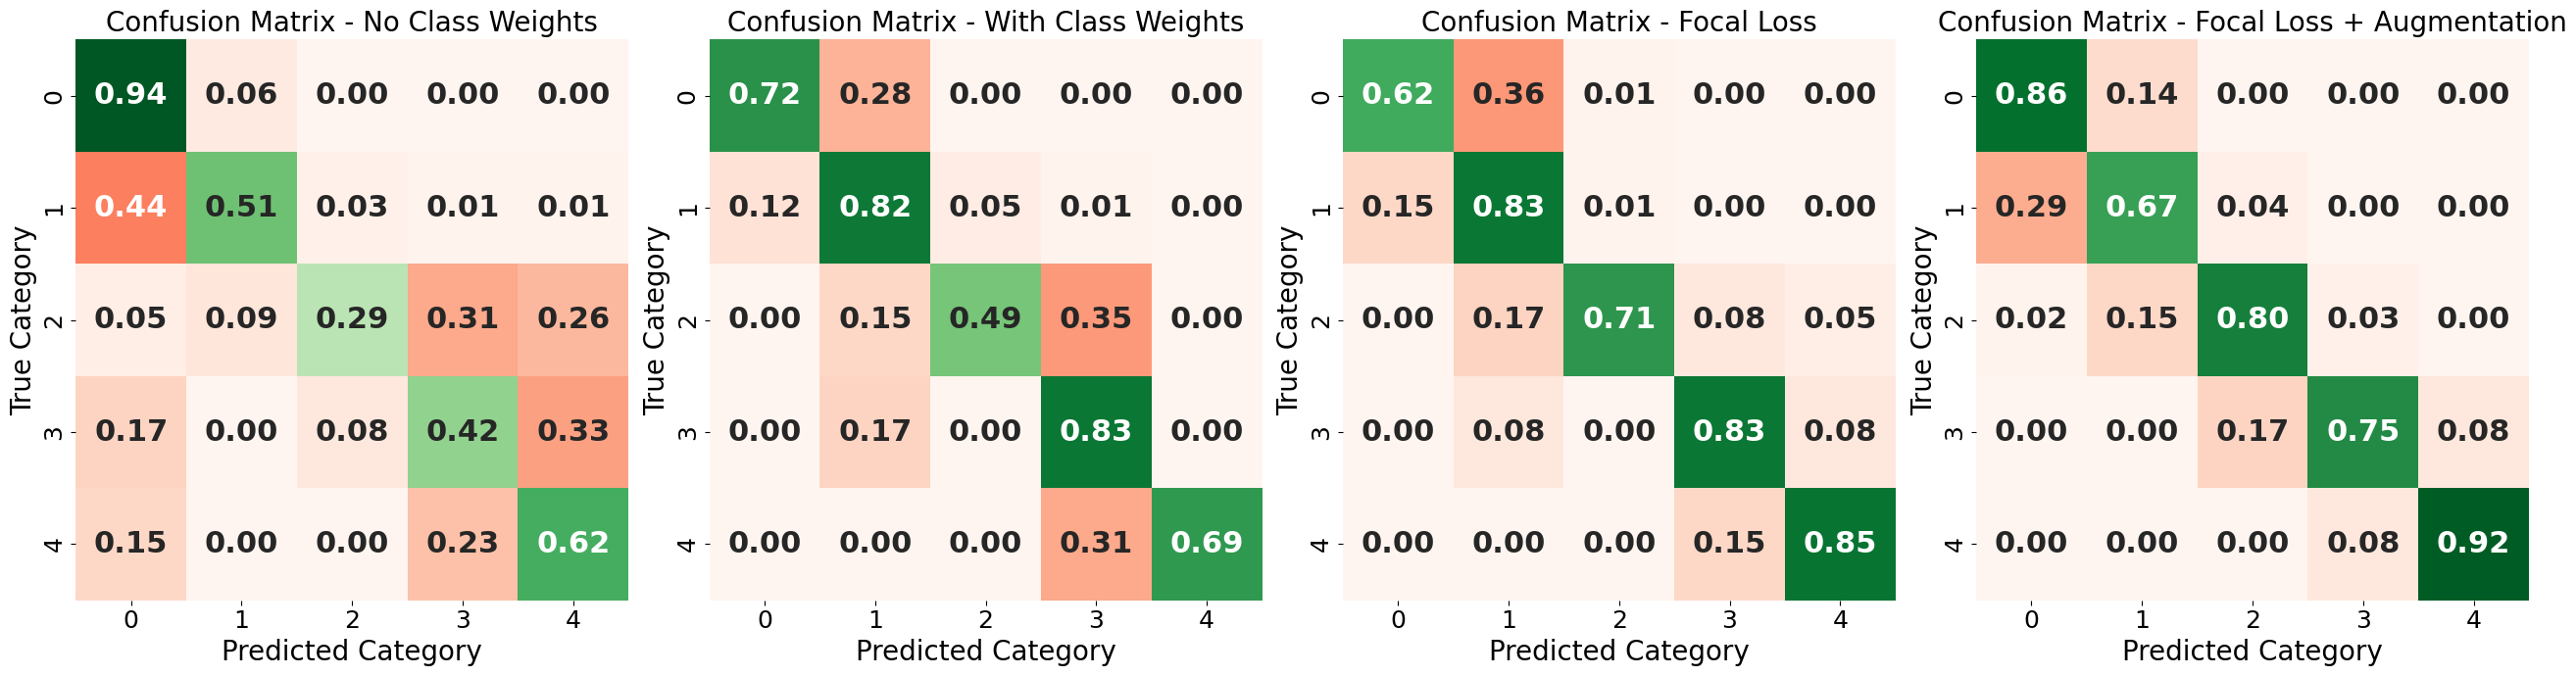

In [66]:
# plot confusion matrices for all 4 models:
plot_all_confusion_matrices_seaborn(
    models=[model, model_class_imbalance, model_focal_loss, model_focal_augmented],
    dataloader=test_dataloader,
    model_names=["No Class Weights", "With Class Weights", "Focal Loss", "Focal Loss + Augmentation"],
    figsize=(26, 7)
)